# <span style='color:deepskyblue'> Cosmology MCMC notebook </span>

## <span style='color:deepskyblue'>Preliminaries</span>

In [1]:
# Install required packages (if not available on server, uncomment the lines below)

!pip3 install --upgrade pip
!pip3 install getdist
!pip3 install numpy
!pip3 install scipy
!pip3 install matplotlib


  Using cached pip-26.0.1-py3-none-any.whl.metadata (4.7 kB)
Using cached pip-26.0.1-py3-none-any.whl (1.8 MB)
  Attempting uninstall: pip
    Found existing installation: pip 26.0
    Uninstalling pip-26.0:
      Successfully uninstalled pip-26.0


In [2]:
 #Load required packages
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import scipy.integrate as integrate

# import pylab
import getdist, IPython, time
from numpy import random

# from IPython.display import Image
from getdist import plots, MCSamples, loadMCSamples

# just for printing! calculations should be performed with machine precision
%precision 3

'%.3f'

(NB: Those equations that you will need to build your code are those $\boxed{\text{with a box around}}$)

## <span style='color:deepskyblue'> The $\Lambda$CDM Model </span>

The Lambda-Cold-Dark-Matter ($\Lambda$CDM) Model is our current "Standard" cosmological model. It postulates a Universe that behaves according to **General Relativity**, filled with **baryons** (protons, neutrons - the stuff we and stars are made of!), **Cold Dark Matter (CDM)** and a **Cosmological Constant** $\Lambda$.

The expansion of the Universe is best described in terms of the **scale factor** $a$ (the "radius" of the Universe, conventionally set to 1 today) and the **Hubble rate** $H$

$$
H \equiv \frac{\dot a}{a} 
$$
Where the dot signifies a time derivative $\dot a \equiv da/dt $

The Einstein Equations in a **homogeneous and isotropic** Universe have an especially simple form and a special name, **Friedmann Equation**:

$$
H^2 = \frac{8\pi G}{3}\rho + \frac{k}{a^2}
$$

where $\rho$ is the total energy density of the Universe (at a certain time or size), and $k$ is a universal constant related to the [spatial curvature and shape of the Universe](https://en.wikipedia.org/wiki/Shape_of_the_universe#:~:text=The%20spatial%20curvature%20is%20related,indistinguishable%20spaces%20with%20different%20topologies.). In the $\Lambda$CDM model (and at late enough times), this additionally simplifies to

$$
\boxed{
H^2 = H_0^2\left(\Omega_\Lambda + \Omega_m a^{-3} + \Omega_k a^{-2}\right)
}
\qquad
\qquad
\boxed{
\Omega_m + \Omega_\Lambda + \Omega_k = 1
}
$$

$H_0$ is the value of the Hubble rate *today*, and the parameters $\Omega_m$, $\Omega_\Lambda$ and $\Omega_k$ are dimensionless quantities indicating how much of the present expansion of the Universe is due to (non-relativistic) matter, cosmological constant $\Lambda$, and spatial curvature $k$. Note that the three $\Omega$'s are *not independent* (their sum is 1) and that we grouped together the contribution of baryons and CDM,

$$
\Omega_m = \Omega_{\rm CDM} + \Omega_{\rm b}
$$

and that we have evidence that independent evidence that $\Omega_b \approx 5$\%. Note that only $\Omega_m \geq 0$ makes physical sense, while in principle both $\Omega_\Lambda$ and $\Omega_k$ can be negative.
In this consideration we are neglecting the contribution of the radiation which becomes negligable after the early stages of expansion.


The present Hubble rate is conventionally parametrised in terms of the dimensionless $h$:

$$
H_0 \equiv h\, \times 100 \left[\frac{ \,\text{km}}{\text{s Mpc}}\right]
$$

where Mpc = Megaparsec and [parsec](https://en.wikipedia.org/wiki/Parsec)  $pc = 3.086 \cdot 10^{16}$ m.

In essence, these equations give us the relation between *what exists in the Universe* and *how the Universe expanded*. Measure one, I can tell you the other. This is precisely what we aim to do!

Time to define the function $H(z)$. Don't forget to include the useful parameters as arguments of the function, and to define `parsec`.

## <span style='color:orange'> Excersise 1 </span>

Write your own code for the Hubble parameter as a function of redshift (z) note that $a = \frac{1}{1+z}$. Make a plot to see if your function works as expected.

In [3]:
# we first define some useful values that we can use throught the code
parsec = 3.086e16 # m
c = 2.998e5 # km/s

# we also define the actual density parameters to test if the data fits well (reference bellow)
Actual_h = 0.704
Actual_Omega_Lambda = 0.73
Actual_Omega_b = 0.0225 / Actual_h**2
Actual_Omega_CDM = 0.112 / Actual_h**2
Actual_Omega_m = Actual_Omega_b + Actual_Omega_CDM


# Hubble rate
def Hubble(z, h, Omega_Lambda, Omega_m):
    z = np.asarray(z, dtype=float) # we set the redshift z to be an array so that we can get also an array from our function
    H0 = h * 100.0 # km/s/Mpc.  we define H0 from the h we give which we will later determine through the data
    Omega_k = 1.0 - Omega_Lambda - Omega_m # calculate Omega_k ignoring radiation because it is negligible
    return H0 * np.sqrt(Omega_Lambda + (Omega_k * (1 + z)**2) + (Omega_m * (1 + z)**3)) # finally returning the value of the Hubble rate

Reference for h and the density parameters:

Lahav, O., & Liddle, A. R. (2011). The cosmological parameters (2011 partial update). In K. Nakamura et al. (Particle Data Group), Review of particle physics. Lawrence Berkeley National Laboratory. Retrieved from https://pdg.lbl.gov/2011/reviews/rpp2011-rev-cosmological-parameters.pdf

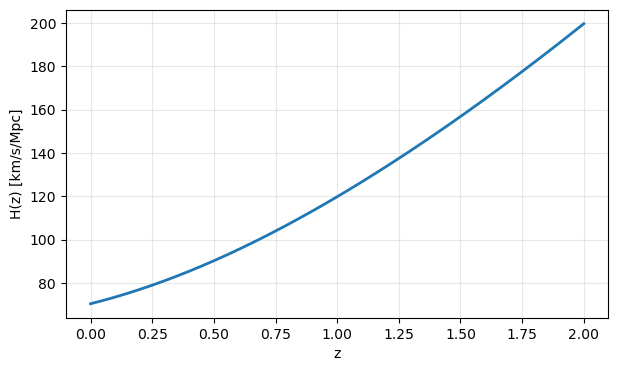

In [4]:
z_plot = np.linspace(0.0, 2.0, 400) # first, we create a smooth grid of redshift values for plotting the theoretical curve

# and we plot the hubble rate against the values of the redshift from 0 to 2
plt.figure(figsize=(7,4))
plt.plot(z_plot, Hubble(z_plot, Actual_h, Actual_Omega_Lambda, Actual_Omega_m), lw=2)
plt.xlabel("z")
plt.ylabel("H(z) [km/s/Mpc]")
plt.grid(alpha=0.3)
plt.show()

Redshift, $z$, is an increidibly useful measure in cosmology, since it correlates with distance, time and velocity. Because the speed of light is finite, the farther away we look the earlier in the universe history we can see. This feature of the universe alone gives us the possibility of researching how the universe has changed throught its lifetime, but more importantly, the universe isn't static. As with the doppler effect of an ambulance passing by, the wavelenghts of light can get streched or squished depending on the direction they are moving with respect to an observer. The faster something moves away, the "redder" it looks, since the wavelengths are streched towards the infrarred regime. Knowing what the wavelenght of something should be and comparing it to what we observe is exactly the feature that allows us measure the velocity at which an object is moving away from us, and as it turns out and it is represrnted in the graph above, the farther away soemthign is, the faster it is moving away from us. But now we want to know exactly what is this expansion rate, so we will find that out.

##  <span style='color:deepskyblue'>Supernovae Ia</span>

In order to track the expansion of the Universe, we will look at Supernovae type Ia observations. SNIa are formed when a *white dwarf* accretes matter from a companion until it reaches a critical mass of about $1.44 M_\odot$ (solar masses), after which it explodes **at always the same luminosity** $L_{\rm SN}$. Therefore, the observed [magnitude](https://en.wikipedia.org/wiki/Magnitude_(astronomy)) is only a function of their [**luminosity distance**](https://en.wikipedia.org/wiki/Distance_measures_(cosmology)) from Earth, defined as the ratio of the intrinsic luminosity $L_{\rm SNIa}$ and the measured *surface brightness* $\Phi$ (energy per unit time per unit area)

$$ d_L\equiv \frac{L_{\rm SN}}{4\pi \Phi} $$

While photons (light rays) travel from the distant SNIa to Earth, the Universe expands and the photons get redshifted, and this redshift is directly related to the size of the Universe when the photon was emitted compared to today:

$$ \frac{\lambda_{\rm obs}}{\lambda_{\rm em}} \equiv 1 + z_{\rm em} = \frac{1}{a_{\rm em}}$$

We can express the luminosity distance in terms of the Hubble rate:

$$
\boxed{
d_L(z) = \frac{c}{H_0}(1+z) \times
\begin{cases}
    \cfrac{1}{\sqrt{\Omega_k}} \,\sinh\left(\sqrt{\Omega_k}\,D(z)\right) & \Omega_k > 0
    \\[.5em]
    D(z) & \Omega_k = 0
    \\[.5em]
    \cfrac{1}{\sqrt{-\Omega_k}} \,\sin\left(\sqrt{-\Omega_k}\,D(z)\right) & \Omega_k < 0
\end{cases}
\qquad\qquad
D(z) \equiv H_0\int_0^z \frac{{\rm d}Z}{H(Z)}
}
$$

where $c$ is the speed of light: $c \simeq 2.998 \cdot 10^{5}$ km/s.

Clearly, there exists a relation between $d_L(z)$ and $H(z)$, so the luminosity distance is a useful measure of the Universe expansion history.

We can create the function `dL(z, h, Omega_m, Omega_Lambda)`. You can also pass the function `Hubble` as an argument: `dL(z, Hubble, Omega_m, Omega_Lambda)`. Additionally, you can create $D(z)$ for your convenience.

Note that you need to integrate the function $H(z)$, so write your own quick-and-easy numerical integrator, for example implementin the [trapezoidal rule](https://en.wikipedia.org/wiki/Trapezoidal_rule) or your favourite alternative, or [look up the pre-written methods](https://docs.scipy.org/doc/scipy/reference/tutorial/integrate.html). Make sure it returns $d_L$ in parsecs and that it uses $h$, which is $H_0$ measured in units of 100 km/s/Mpc!

## <span style='color:orange'> Excersise 2 </span>

Define a function that calculate the luminosty distance in flat ($\Omega_k = 0$) and both possitively and negatively curved  ($\Omega_k \neq 0$) spacetime.

In [5]:
# we define our function for dL passing the redshift, h, Omega_m and Omega_Lambda (which we will determine later through the MCMC)

def theor_luminosity_distance(z, h, Omega_m, Omega_Lambda):
    H0 = h * 100.0 # km/s/Mp  first we set H0 from h
    Omega_k = 1.0 - Omega_Lambda - Omega_m # then we once again determine Omega_k

    z_arr = np.atleast_1d(z).astype(float) # first, we force z to be a float array so we can loop over it
    dL_pc = np.empty_like(z_arr) # then, we allocate an empty array to store d_L(z) for each redshift

    # we then loop over each value zi in our z array
    for i, zi in enumerate(z_arr):
        
        # we define the integrand for our D(z) function, since the integrating function expects a function as an argument
        def Dz_integrand(Z, h, Omega_Lambda, Omega_m):
            return 1.0 / Hubble(Z, h, Omega_Lambda, Omega_m)

        # we then use the quad function from sci py to integrate the integrand that 
        # we defined in the previous line in the bounds of 0 to zi (which we are iteratating over)
        Dz_integral, error = integrate.quad(Dz_integrand, 0.0, float(zi), args=(h, Omega_Lambda, Omega_m))

        # finally we get D(z) by multiplying the integral by H0
        Dz = H0 * Dz_integral

        # now we choose which S_k to get depending on the curvature density 
        if Omega_k > 0.0: # positively curved (open) universe
            Sk = np.sinh(np.sqrt(Omega_k) * Dz) / np.sqrt(Omega_k)
        elif Omega_k < 0.0: # negatively curved (closed) universe
            Sk = np.sin(np.sqrt(-Omega_k) * Dz) / np.sqrt(-Omega_k)
        else:
            Sk = Dz # flat universe

        # finally, we compute the luminosity distance:
        # d_L = (c/H0) (1+z) S_k(D), and convert from Mpc to parsecs.
        dL_Mpc = (c / H0) * (1.0 + zi) * Sk
        dL_pc[i] = dL_Mpc * 1e6

    # here we control in the case that we pass just one value to the function for it to return it as the first index of the array, 
    # but if it is not, then we just return teh array
    return dL_pc[0] if np.isscalar(z) else dL_pc




## <span style='color:deepskyblue'>The Union2.1 Compilation</span>

Our source of data is from [Union2.1](http://supernova.lbl.gov/Union/). It is a collection of $580$ SNIa, each observation is comprised of redshift $z$ and [distance modulus](https://en.wikipedia.org/wiki/Distance_modulus) $\mu$ (and corresponding errors $\delta\mu$), defined as the difference between the *apparent magnitude* $m$ and the *absolute magnitude* $M$:

$$
\boxed{
\mu(z) \equiv m(z) - M \equiv 5 \log_{10} \frac{d_L(z)}{10\,\text{pc}}
}
$$

Our goal today is to use SNIa measurements to constrain the parameters ($h, \Omega_\Lambda, \Omega_m$).

In essence, we can calculate for each redshift the theoretical value of $\mu$ using this equation with the expression for $d_L(z)$ and our model of choice $H(z)$ -- note that we will need to perform a numerical integral! -- and compare this value with observations. A different model would amount to changing the theoretical value of $H(z)$.

Let us start by importing and plotting the data:

In [6]:
dataloc = "http://supernova.lbl.gov/Union/figures/SCPUnion2.1_mu_vs_z.txt"

# Read in data as numpy array.
# Format is [name, redshift, magnitude, magnitude error, and another number?]
data = np.genfromtxt("SCPUnion2.1_mu_vs_z.txt")

# Print the first line as an example. (Note that genfromtxt turns the names into 'Not A Number')
display(data[0])

array([      nan, 2.849e-02, 3.535e+01, 2.239e-01, 1.284e-01])

In [7]:
# Extract the redshifts (zs), distance modulus (dist_mod) and magnitude estimated errors (err_dist_mod)
# Data are in columns, so we either slice it by columns: arr[:,n]...

# we load the data in columns
zs = data[:,1]
distance_modulus = data[:,2]
error_distance_modulus = data[:,3]

In [8]:
# Let's look at the data, just for fun.
# We can look both at the raw data (distance modulus) or calculate the luminosity distance
# Note that Numpy allows us to manipulate whole arrays at once with something like:
#     array_2 = some_function_of(array_1)

# luminosity distance in pc
luminosity_distance_pc = 10. * 10.**(distance_modulus / 5.)

# and in Mpc
luminosity_distance_Mpc = luminosity_distance_pc / 10.**6

# and the error on that distance:
error_luminosity_distance_Mpc = 5. * (10.**((distance_modulus + error_distance_modulus)/5.-6.) - 10.**((distance_modulus - error_distance_modulus)/5.-6.))

Recommendation: plot the data so you can see the luminosity distance and distance modulus as a function of the redshift

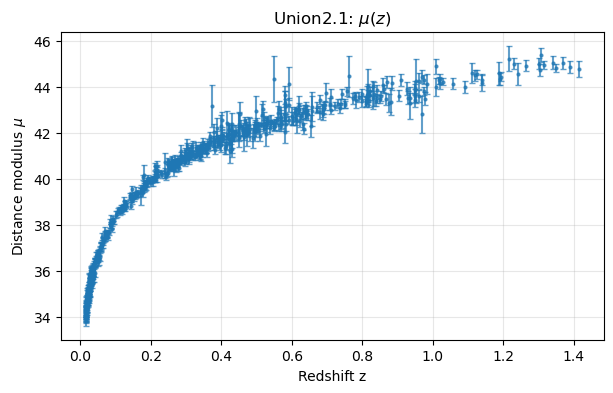

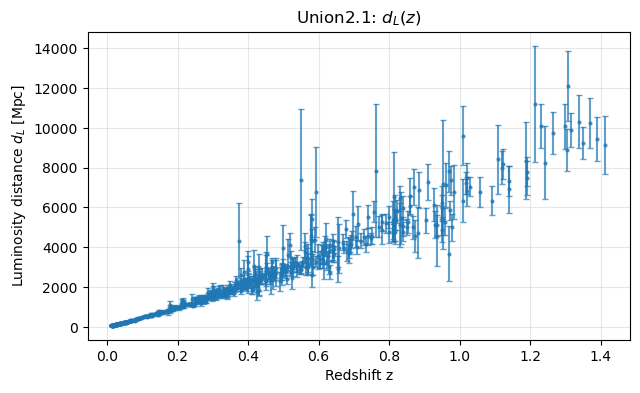

In [9]:
%matplotlib inline

# here we plot the data

# distance modulus vs redshift
plt.figure(figsize=(7,4))
plt.errorbar(zs, distance_modulus, yerr=error_distance_modulus, fmt='.', ms=4, alpha=0.7, capsize=2)
plt.xlabel('Redshift z')
plt.ylabel(r'Distance modulus $\mu$')
plt.title('Union2.1: $\mu(z)$')
plt.grid(alpha=0.3)
plt.show()

# luminosity distance vs redshift
plt.figure(figsize=(7,4))
plt.errorbar(zs, luminosity_distance_Mpc, yerr=error_luminosity_distance_Mpc, fmt='.', ms=4, alpha=0.7, capsize=2)
plt.xlabel('Redshift z')
plt.ylabel(r'Luminosity distance $d_L$ [Mpc]')
plt.title('Union2.1: $d_L(z)$')
plt.grid(alpha=0.3)
plt.show()

## <span style='color:orange'> Excersise 3 </span>

Now also define a function to calculate the distance modulus using your previously defined luminosity distance function. Use these functions to plot the theoretical curves as a function of redshift and compare with the data. (Does the line go through the data points?)

In [10]:
# we define a function for the thistance modulus mu given the parameters h, Omega_m, Omega_Lambda as a function of redshift z
def theor_distance_modulus(z, h, Omega_m, Omega_Lambda):
    dL_pc = theor_luminosity_distance(z, h, Omega_m, Omega_Lambda)
    return 5.0 * np.log10(dL_pc / 10.0)

# we create a grid of values for the redshift between 0.01 and 2.0
z_line = np.linspace(0.01, 2.0, 300)
# we pass the actual values we have throught the distanc modulus function
mu_line = theor_distance_modulus(z_line, Actual_h, Actual_Omega_m, Actual_Omega_Lambda)
# and we do the same for our luminosity distance (dividin the result by 1e6 to get Mega parsecs)
dL_line_Mpc = theor_luminosity_distance(z_line, Actual_h, Actual_Omega_m, Actual_Omega_Lambda) / 1e6

Try your functions here. Make atleast two plots to check that for $\Omega_m = 0.3$, $\Omega_\Lambda = 0.7$ and $h =0.7$ your theory calculations of the luminosity distance and the distance modulus match okay to the data for redshifts ranging from ~0.1 to 2.

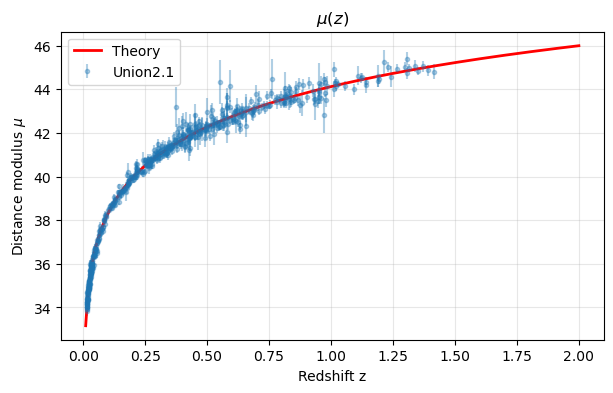

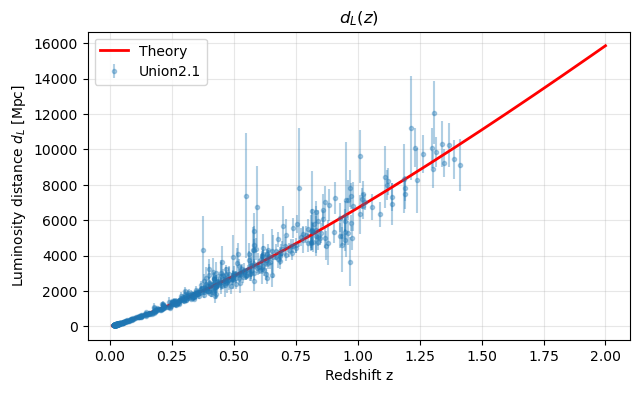

In [11]:
# here we plot the figures once again with the theoretical predictions overalyed to compare them

# distance modulus vs redshift
plt.figure(figsize=(7,4))
plt.errorbar(zs, distance_modulus, yerr=error_distance_modulus, fmt='.', alpha=0.35, label="Union2.1")
plt.plot(z_line, mu_line, 'r', lw=2, label="Theory")
plt.xlabel('Redshift z')
plt.ylabel(r'Distance modulus $\mu$')
plt.title('$\mu(z)$')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# luminosity distance vs redshift
plt.figure(figsize=(7,4))
plt.errorbar(zs, luminosity_distance_Mpc, yerr=error_luminosity_distance_Mpc, fmt='.', alpha=0.35, label="Union2.1")
plt.plot(z_line, dL_line_Mpc, 'r', lw=2, label="Theory")
plt.xlabel('Redshift z')
plt.ylabel(r'Luminosity distance $d_L$ [Mpc]')
plt.title('$d_L(z)$')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

As we can see, unsurprisingly, the actual currently accepted values for $h$, $\Omega_m$ and $\Omega_\Lambda$ match the Union 2.1 data remarkably well, at least at a first glance. (I'm sorry for not doing an analysis on how well the data fits it, it was not required and I was very sleepy by the point I was writing my comments and I realized at no point we see how well the accepted values fit the data, but we did do that for the MCMC so technically we did it anyways since the actual data was obtained that way I assume, anyways, don't listen to me Rens I am just tired and rambling on my comments)

## <span style='color:deepskyblue'>Bayes' Theorem: Likelihood, Prior, Posterior (and Evidence...)</span>

The **conditional probability of A given that B is true** is denoted with $P(A|B)$ (read: *probability of A given B*).
Did A happen? Then B has probability $P(B|A)$ of happening.

[**Bayes' Theorem**](https://en.wikipedia.org/wiki/Bayes%27_theorem) is simply a reflection of the symmetry of the concept of joint probability:

$$
P(A|B)P(B) = P(B|A)P(A)
$$

In physics, our goal is often to determine how likely the values of some parameters $\theta$ are, given how well they reproduce the data $D$.
We write Bayes' theorem in the following equivalent form:

$$
P(\theta | D) = \frac{P(D|\theta)P(\theta)}{P(D)}
$$

The various terms conventionally take the names:

$$
\begin{aligned}
P(\theta | D) & && \text{Posterior}
\\
P(D | \theta)& && \text{Likelihood}
\\
P(\theta) & && \text{Prior}
\\
P(D) & && \text{Evidence}
\end{aligned}
$$

### <span style='color:deepskyblue'>Prior</span>

The *prior* quantifies our degree of prior belief in the model parameters. It can contain the results of previous experiments, or theoretical considerations (for instance, that certain parameters cannot be negative, etc.).

We can have *strong priors* about something - the Sun still existing at night, see the comic below - or not.
When we do *not* have compelling prior knowledge about a parameter, we generally use a *non-informative* prior probability distribution, most often related to the [uniform distribution](https://en.wikipedia.org/wiki/Continuous_uniform_distribution)

$$
\begin{aligned}
    \text{Uniform} & && \theta \in \text{Uniform}[\theta_{\rm min}, \theta_{\rm max}]
    \\
    \text{Log Uniform} & && \log\theta \in \text{Uniform}[\log\theta_{\rm min}, \log\theta_{\rm max}]
\end{aligned}
$$

You may sometimes hear that "the prior doesn't matter". While this is not strictly true, it is however true that in many instances the *likelihood* depends more dramatically on the parameters and will have a dominating contribution to the posterior. You are more than welcome to try different priors for the model parameters and see if and how your results change.

### <span style='color:deepskyblue'>Likelihood</span>

The measure of how well our model reproduces the data is the **likelihood** $\mathcal L$. For normal (=Gaussian), uncorrelated data $\mu_i$ with errors $\sigma_i$ ($i = \{1,580\}$), the likelihood is related to the famous [**chi-squared**](https://en.wikipedia.org/wiki/Chi-square_distribution) via

$$
P(D | \theta) \equiv \mathcal L = \exp\left(-\frac{\chi^2}{2}\right)
\qquad
\qquad
\boxed{
\chi^2 \equiv \sum_{i=1}^{580} \frac{\left(\mu_i^{(\rm theor)} - \mu_i^{(\rm obs)}\right)^2}{\sigma_i^2}
}
$$

A *high likelihood* corresponds to a *low chi squared*.

In principle, we could attack the problem brute-force: create a grid of values for $h$, $\Omega_m$, $\Omega_\Lambda$, calculate the likelihood for each combination, and create a profile for the likelihood.

In practical cases, however, this is not only sub-optimal but sometimes **impossible**. Think of complicated models with 20+ free parameters (this is not that unusual in physics, by the way). Even a very coarse grained grid of 100 values for each parameter would result in more than $10^{40}$ (!!!) different parameter combination to be tested. You can probably understand why this is undesirable.

### <span style='color:deepskyblue'>Evidence</span>

This is the tricky bit. The evidence, which is "*the probability of observing certain data*", is not something that is easy to evaluate or interpret. This looks like a serious limitation to finding the:


### <span style='color:deepskyblue'>Posterior</span>

What does the data tell us about the model parameters? The answer is the *posterior probability distribution*, often (but not necessarily) expressed as (average $\pm$ standard deviation)

$$
\theta_i = \bar\theta_i \pm \sigma_i
$$

In other words, the posterior tells us how likely it is for the model parameters to have certain values, *given that we observe the data* $D$.

*This is the final goal of our analysis!*

<br>

![title](http://1.bp.blogspot.com/-tTx4HDejSww/ULcTeK9_V_I/AAAAAAAAA8g/PCYOH-eXGbk/s1600/frequentists_vs_bayesians.png)
![title](https://i.redd.it/5r0hwixt0m931.jpg)

## <span style='color:deepskyblue'>Markov-Chain Monte Carlo</span>

Markov-Chain Monte Carlo techniques are a class of methods to sample a probability distribution $P(x)$ - in our case $P(\theta | D)$ - provided that we can calculate a density $\mathcal F(x)$ **that is proportional to it** - in our case $P(\theta)P(D|\theta)$ = likelihood $\times$ prior. Among these, a very popular one is the [**Metropolis-Hastings**](https://en.wikipedia.org/wiki/Metropolis%E2%80%93Hastings_algorithm) algorithm, which is what we will use.

Schematically, the algorithm works as follows:
* Start with an $n$-tuple of parameters $\theta_{\rm old} = \{\theta_1, \theta_2, \dots\}_{\rm old}$ (in our case $\theta = \{h,\Omega_m,\Omega_\Lambda\}$) and calculate the $\mathcal F_{\rm old}$
* Propose a new set of parameters $\theta_{\rm prop}$, calculate the new corresponding $\mathcal F_{\rm prop}$. How you propose the new parameters is not essential as long as the probability of going from one set of parameters to the next is the same as the inverse: $P(\theta_a \to \theta_b) = P(\theta_b \to \theta_a)$. For this, we normally take Gaussian displacements with some (relatively small) standard deviation.
* Compare the new and old likelihoods-priors:
    * If $\mathcal F_{\rm prop} > \mathcal F_{\rm old}$, accept the step: $\theta_{\rm new} = \theta_{\rm prop}$
    * Otherwise, accept with probability $P_{\rm accept} = \mathcal F_{\rm prop}/\mathcal F_{\rm old}$
* If accepted, $\theta_{\rm new} = \theta_{\rm prop}$ and record the step; otherwise, $\theta_{\rm new} = \theta_{\rm old}$ (no re-recording)
* Update $\theta_{\rm old} = \theta_{\rm new}$
* Repeat

The MC chain keeps going until the desired number of steps or, ideally, when a suitable convergence test, like for example the [Gelman-Rubin test](https://bookdown.org/rdpeng/advstatcomp/monitoring-convergence.html), is satisfied.
Today we will just set a limit to the total number of steps, but please feel free to implement and test your favourite convergence test!

Looking at equation (4), you can convince yourself that
$$
\frac{\mathcal L_a}{\mathcal L_b} = \exp\left(\frac{\chi_b^2 - \chi_a^2}{2}\right)
$$

(This is useful because $\chi^2$ can be large, so we want to avoid the likelihoods evaluating to `0.` -- computers don't like dividing by zero, unfortunately)

* Start with an $n$-tuple of parameters $\theta_{\rm old} = \{\theta_1, \theta_2, \dots\}_{\rm old}$ (in our case $\theta = \{h,\Omega_m,\Omega_\Lambda\}$) and the corresponding chi squared $\chi_{\rm old}^2$ (to be clear, for us this implies calculating a series of 580 integrals and comparing each with the observed values)
* Propose new parameters $\theta_{\rm prop}$ and calculate the corresponding chi squared $\chi_{\rm prop}^2$
* Draw a random number $r \in [0,1]$
* Accept the step if
$$
r < \exp\left(\frac{\chi_{\rm old}^2 - \chi_{\rm prop}^2}{2}\right) \frac{P(\theta)_{\rm prop}}{P(\theta)_{\rm old}}
$$
* If accepted, update $\theta_{\rm old} = \theta_{\rm prop}$, and record; otherwise, $\theta_{\rm new} = \theta_{\rm old}$ (no re-recording)
* Repeat

##  <span style='color:orange'> Excersise 4 </span>

Write your own code to perform a Monte Carlo Markov Chain. Note that your algorithm should be robust and converge to the correct parameters even for poor initial guesses.

In [13]:
from random import random
from random import gauss
import sys


# we define the prior and use it to reject unphysical parameter values
def prior_ok(h, Omega_m, Omega_Lambda):
    # h must be positive because H0 = 100 h km/s/Mpc
    if h <= 0.0:
        return False

    # negative matter density is unphysical
    if Omega_m < 0.0:
        return False

    # we compute the curvature parameter from the Friedmann constraint
    Omega_k = 1.0 - Omega_m - Omega_Lambda

    # after that, we build a redshift grid covering the data range
    z_test = np.linspace(0.0, np.max(zs), 300)

    # here, we evaluate the dimensionless H(z)^2 / H0^2 combination
    E2 = Omega_m * (1.0 + z_test)**3 + Omega_k * (1.0 + z_test)**2 + Omega_Lambda

    # and finally we keep only points where H(z)^2 stays positive
    return np.all(E2 > 0.0)


# we define the chi-squared used to compare theory to the data
def calculate_chi2(h, Omega_m, Omega_Lambda):
    # first, we check that the proposed point satisfies the prior
    if not prior_ok(h, Omega_m, Omega_Lambda):
        return np.inf

    # next we calculate the theoretical distance modulus at all observed redshifts
    mu_th = theor_distance_modulus(zs, h, Omega_m, Omega_Lambda)

    # we reject the point if the theory gives invalid values
    if np.any(~np.isfinite(mu_th)):
        return np.inf

    # and we compute the Gaussian chi-squared from the notebook definition
    chi2 = np.sum(((mu_th - distance_modulus) / error_distance_modulus)**2)
    return chi2


#  we choose the filename that will later be used in exercises 5 and 6
filename = "MC_Chain_SNIa.txt"

# then we set how many accepted points we want in the chain
N_steps = 15000

# accepted counts how many points have been accepted and saved
accepted = 0

# total counts how many proposals have been tried
total = 0

# next we choose the widths of the Gaussian proposal steps
step_h = 0.01
step_Omega_m = 0.02
step_Omega_Lambda = 0.02

# now we start from a rough initial guess
h_old = 0.55
Omega_m_old = 0.60
Omega_Lambda_old = 0.20

# we compute the chi-squared of that starting point
chi2_old = calculate_chi2(h_old, Omega_m_old, Omega_Lambda_old)

# if the starting point is invalid, we keep drawing a new one until it works
while not np.isfinite(chi2_old):
    h_old = np.random.uniform(0.4, 1.0)
    Omega_m_old = np.random.uniform(0.0, 1.0)
    Omega_Lambda_old = np.random.uniform(-1.0, 2.0)
    chi2_old = calculate_chi2(h_old, Omega_m_old, Omega_Lambda_old)

# before the chain starts, we print a progress message
print("Progress:")

# finally, we start the timer
start = time.time()

# we open the output file and write the accepted chain points into it
with open(filename, "w") as file:
    # first, the header stores the meaning of each column
    file.write("# step h Omega_m Omega_Lambda chi2\n")

    # then we keep going until we have exactly N_steps accepted samples
    while accepted < N_steps:
        # each loop is one proposal
        total += 1

        # next we propose a new value of h
        h_prop = gauss(h_old, step_h)

        # in the same way we propose a new value of Omega_m
        Omega_m_prop = gauss(Omega_m_old, step_Omega_m)

        # and we do the same for Omega_Lambda
        Omega_Lambda_prop = gauss(Omega_Lambda_old, step_Omega_Lambda)

        # we now calculate the chi-squared of the proposed point
        chi2_prop = calculate_chi2(h_prop, Omega_m_prop, Omega_Lambda_prop)

        # if the proposal is invalid we skip it and move to the next one
        if not np.isfinite(chi2_prop):
            continue

        # first if the new point has a lower chi-squared, we accept it automatically
        if chi2_prop < chi2_old:
            accept = True

        # otherwise we accept it with the Metropolis-Hastings probability
        else:
            # here we work in log-space for numerical stability (chat gpt told me that, I am not proud of turning to a clanker for help)
            log_alpha = 0.5 * (chi2_old - chi2_prop)

            # then we draw a random number and compare it to the acceptance probability
            log_r = np.log(max(random(), 1e-300))
            accept = (log_r < log_alpha)

        # if the step is accepted, we update the chain position
        if accept:
            h_old = h_prop
            Omega_m_old = Omega_m_prop
            Omega_Lambda_old = Omega_Lambda_prop
            chi2_old = chi2_prop

            # after that, we increase the number of accepted samples
            accepted += 1

            # we save the accepted point in the format needed for exercises 5 and 6
            file.write(
                f"{accepted} {h_old:.8f} {Omega_m_old:.8f} {Omega_Lambda_old:.8f} {chi2_old:.8f}\n"
            )

            # finally, we print an update every 1000 accepted samples
            if accepted % 1000 == 0:
                print(f"{accepted}/{N_steps}")

# once the chain is finished, we stop the timer
end = time.time()

# in the end we print the acceptance ratio
print("Done! Acceptance ratio =", accepted / total)

# and we print the total runtime
print("time required: {:.2f} s".format(end - start))

Progress:
1000/15000
2000/15000
3000/15000
4000/15000
5000/15000
6000/15000
7000/15000
8000/15000
9000/15000
10000/15000
11000/15000
12000/15000
13000/15000
14000/15000
15000/15000
Done! Acceptance ratio = 0.23802723031514805
time required: 1850.48 s


In essence this is automatized gambling, which is no fun, because I don't get to do the gambling, yet another joy of life robots have stolen from us.

After completion of the programme, your MC chain will (*hopefully*) look something like this:

`#Omega_m  Omega_L  h`

`0.297     0.703    0.698`

`0.285     0.715    0.701`

`0.288     0.712    0.699`

`...`

## <span style='color:deepskyblue'>Plotting: GetDist</span>

We will do the plots with [`GetDist`](https://getdist.readthedocs.io/en/latest/plot_gallery.html).

The plot gallery contains a lot of useful examples, you should be able to read them fairly easily and see which applies to your situation. Look for both (triangle) plots and for parameter estimation.

Note that many `GetDist` functions require arguments of type `MCSamples`; make sure you convert your lists accordingly.

##  <span style='color:orange'> Excersise 5 </span>

Use the GetDist functions in the example given underneath but with your **own** MCMC data to generate investigate the sampling of the MCMC.

(10501, 4)
Removed no burn in
0.7  <  h  <  0.7  at  68% CL
0.21  <  Omega_m  <  0.35  at  68% CL
0.6  <  Omega_Lambda  <  0.85  at  68% CL
-0.19  <  Omega_k  <  0.19  at  68% CL




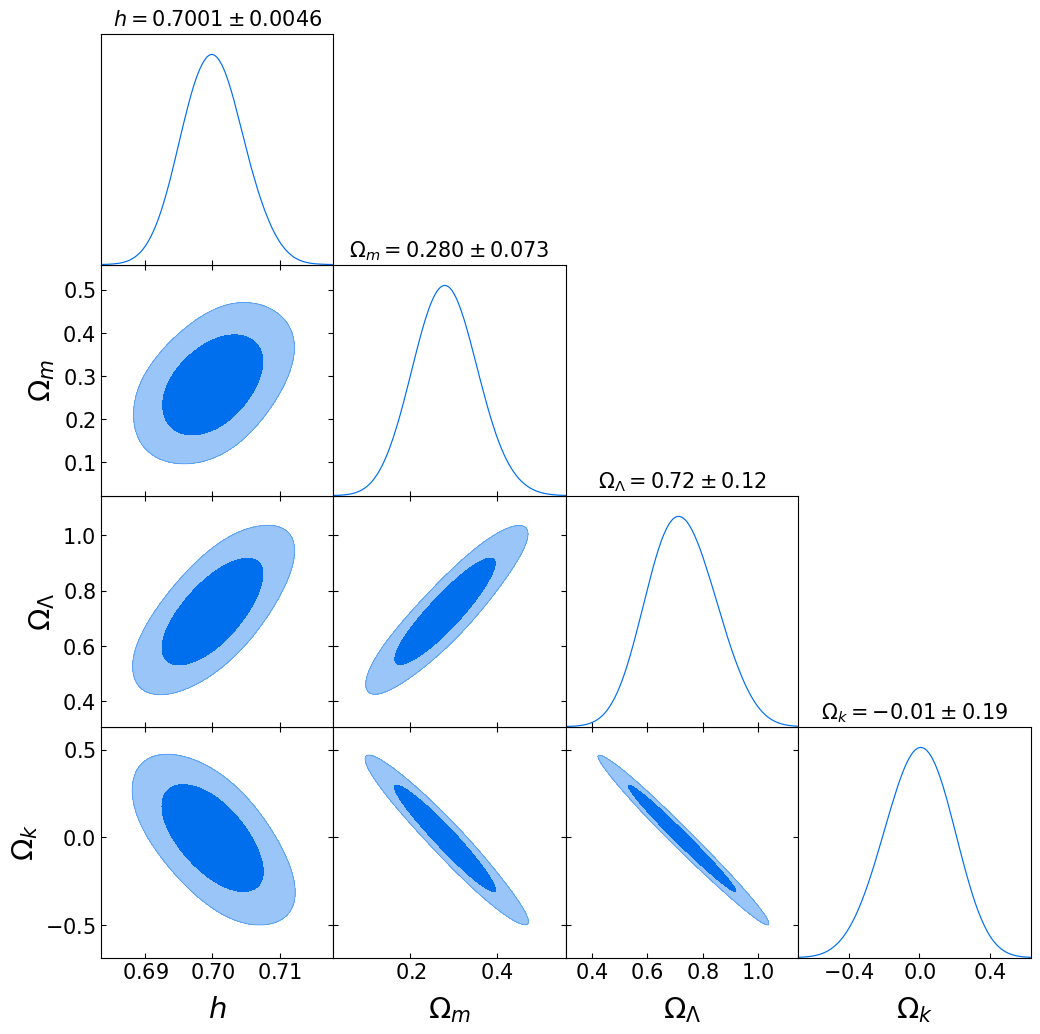

In [15]:
filename = "MC_Chain_SNIa.txt"
datafile = np.loadtxt(filename,
                      skiprows=int(0.3 * N_steps)) # remove some burn-in

h, Omega_m, Omega_Lambda, chi2 = datafile[:,1], datafile[:,2], datafile[:,3], datafile[:,4]

# You can easily create new np.arrays that are functions of other np.arrays
Omega_k = 1. - Omega_m - Omega_Lambda

# Let's define variable names and labels
my_labels = [r'h', r'\Omega_m', r'\Omega_\Lambda', r'\Omega_k']
my_names = ['h', 'Omega_m', 'Omega_Lambda', 'Omega_k']
my_dim = len(my_names) # The number of variables we're plotting

# This creates a higher-dimensional array with all our data, shaped in the appropriate way...
my_samples = np.transpose(np.reshape([h, Omega_m, Omega_Lambda, Omega_k], (my_dim, len(h))))
print(np.shape(my_samples))

# ... to create an "MCSamples" data type, which GetDist can use
my_samples = MCSamples(samples = my_samples, labels = my_labels, names = my_names)

# The usual 1-sigma confidence level. You can change to 2- or 3-sigma if you want
conf_level = 0.6827

# This prints a table with the 1D posteriors (confidence levels)
for nam in my_names:
    print(round(my_samples.confidence(nam,(1.-conf_level)/2.,upper=False),2), \
          " < ", nam , " < ", round(my_samples.confidence(nam,(1.-conf_level)/2.,upper=True),2),\
          " at " , int(100*conf_level),"\b% CL")
print("\n")

#Triangle corner plot
j = plots.getSubplotPlotter(subplot_size=3)
j.settings.axes_labelsize = 22
j.settings.axes_fontsize = 16
j.triangle_plot(my_samples, filled = True, title_limit=1)

As I understood, the first part of the chain is biased by the initial guess, so we remove 30% so that data deosn't skew our actual predictions from the model, as a matter of fact I ran the analysis without getting rid of the first 30% and saw that the results did change: $h$ and $\Omega_m$ barely changed on the central values, $\Omega_\Lambda$ changed a bit more but $\Omega_k$ did change signlificantly from 0.07 to 0.05 (yes this was the most significant change, I know it is almost nothing), I would assume this is because we obtain $\Omega_k$ from $\Omega_m$ and $\Omega_\Lambda$, so the bias propagates. Anyways, these values we get are remarkably close to the actual ones:

| Parameter | Actual | MCMC | Error |
|-----------|-------:|-----:|------:|
| $h$ | 0.704 | 0.6989 | 0.0051 |
| $\Omega_m$ | 0.2714 | 0.254 | 0.0174 |
| $\Omega_\Lambda$ | 0.73 | 0.68 | 0.0500 |
| $\Omega_k$ | -0.0013794550619835033 | 0.07 | 0.0713794550619835 |

Obviously it is not perfect and I assume that they take in larger surveys of thata in the actual analysis to get the values. But from this naive analysis we did we could certainly say that the $\Lambda\mathrm{CDM}$ model is the one that fits the results better.

I assumed that we were just supposed to use the code as given and that was it. Can't beleive I'm saying this, but I'm a bit dissapointed we didn't get to code this ourselves, but at the same time I am very lazy and I will do a sacrifise to which ever god you pray to thank you for your misericordy of just giving us code that works.

In [16]:
print(my_samples.getParamNames())

h	h
Omega_m	\Omega_m
Omega_Lambda	\Omega_\Lambda
Omega_k	\Omega_k



##  <span style='color:orange'> Excersise 6 </span>

Show the curves for $d_L$ and/or $\mu$ as a function of redshift using the best fit parameters determined using your MCMC code, so you will need to make use of your earlier defined functions for $d_L$ and $\mu$ . Check if this correctly reproduces the data. Additionally, provide an extimate on the error and plot the corresponding confidence intervals based on the sample that your MCMC code produces. 

Best-fit values:
h = 0.70001224
Omega_m = 0.27890589
Omega_L = 0.72261411

68% confidence intervals:
0.69543083 < h < 0.70465552
0.20744378 < Omega_m < 0.35249747
0.60272091 < Omega_L < 0.84925765


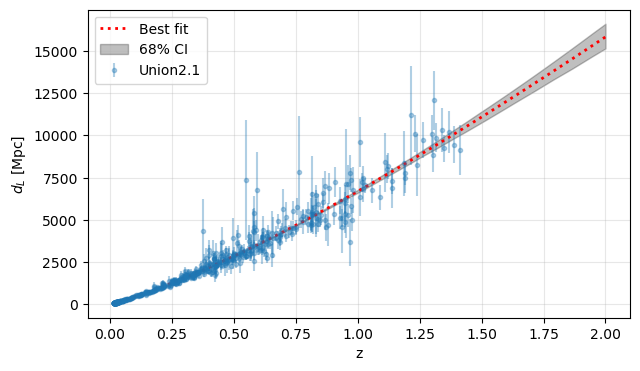

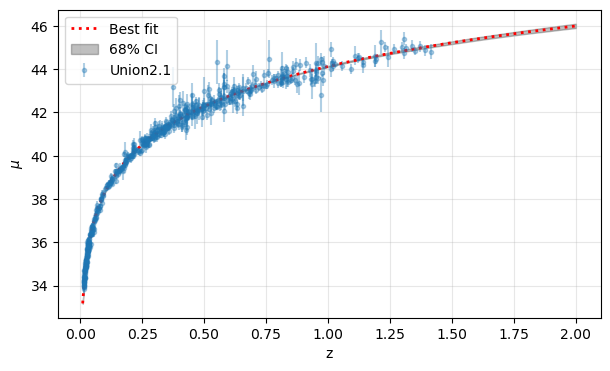

In [17]:

##Example of how to get the confidence intervals from your MCMC samples
h_min = my_samples.confidence('h',(1.-conf_level)/2.,upper=False)
h_max = my_samples.confidence('h',(1.-conf_level)/2.,upper=True)

Omega_M_min = my_samples.confidence('Omega_m',(1.-conf_level)/2.,upper=False)
Omega_M_max = my_samples.confidence('Omega_m',(1.-conf_level)/2.,upper=True)

Omega_L_min = my_samples.confidence('Omega_Lambda',(1.-conf_level)/2.,upper=False)
Omega_L_max = my_samples.confidence('Omega_Lambda',(1.-conf_level)/2.,upper=True)


# the best-fit point is the one with the minimum chi2 in the chain, so we get those
best_idx = np.argmin(chi2)
h_best = h[best_idx]
Omega_M_best = Omega_m[best_idx]
Omega_L_best = Omega_Lambda[best_idx]

# once more we setup a redshift grid where the theory curves will be evaluated
z_plot = np.linspace(0.01, 2.0, 250)

# now, we calculate the best-fit luminosity distance and distance modulus
dL_best = theor_luminosity_distance(z_plot, h_best, Omega_M_best, Omega_L_best) / 1e6 # in mega parces
mu_best = theor_distance_modulus(z_plot, h_best, Omega_M_best, Omega_L_best)

# we use a subset of the MCMC samples to estimate the confidence bands
rng = np.random.default_rng(42)
n_draw = min(250, len(h))
idx = rng.choice(len(h), size=n_draw, replace=False)

# here we calculate mu(z) for many posterior samples
mu_draw = np.array([
    theor_distance_modulus(z_plot, h[i], Omega_m[i], Omega_Lambda[i])
    for i in idx
])

# in the same way we calculate d_L(z) for many posterior samples
dL_draw = np.array([
    theor_luminosity_distance(z_plot, h[i], Omega_m[i], Omega_Lambda[i]) / 1e6
    for i in idx
])

# from these samples we take the 16th and 84th percentiles for the 68% interval
mu_lo, mu_hi = np.percentile(mu_draw, [16, 84], axis=0)
dL_lo, dL_hi = np.percentile(dL_draw, [16, 84], axis=0)

# we print the best-fit values from the chain
print("Best-fit values:")
print("h =", h_best)
print("Omega_m =", Omega_M_best)
print("Omega_L =", Omega_L_best)

# amd we also print the 68% confidence intervals
print("\n68% confidence intervals:")
print(h_min, "< h <", h_max)
print(Omega_M_min, "< Omega_m <", Omega_M_max)
print(Omega_L_min, "< Omega_L <", Omega_L_max)




# plot your d_L and mu together with the data to compare
# first, we plot d_L(z) together with the data and the 68% confidence band
plt.figure(figsize=(7,4))
plt.errorbar(zs, luminosity_distance_Mpc, yerr=error_luminosity_distance_Mpc,
             fmt='.', alpha=0.35, label='Union2.1')
plt.plot(z_plot, dL_best, color='red', linestyle=':', lw=2, label='Best fit')
plt.fill_between(z_plot, dL_lo, dL_hi, color='black', alpha=0.25, label='68% CI')
plt.xlabel('z')
plt.ylabel(r'$d_L$ [Mpc]')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# then, we plot mu(z) together with the data and the 68% confidence band
plt.figure(figsize=(7,4))
plt.errorbar(zs, distance_modulus, yerr=error_distance_modulus,
             fmt='.', alpha=0.35, label='Union2.1')
plt.plot(z_plot, mu_best, color='red', linestyle=':', lw=2, label='Best fit')
plt.fill_between(z_plot, mu_lo, mu_hi, color='black', alpha=0.25, label='68% CI')
plt.xlabel('z')
plt.ylabel(r'$\mu$')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


As we can see the confidence intervals from the MCMC data fit the theoretical estimation pretty well, up to the regime in $z$ where there is no data, at that point is where theys start deviating but not much.